<a href="https://colab.research.google.com/github/aparna-2001/system-biology/blob/main/systems_biologyipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip uninstall -y numpy scipy
!pip install tellurium


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 53.6 MB/s eta 0:00:00
   ━━

In [1]:
import tellurium as te
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import networkx as nx

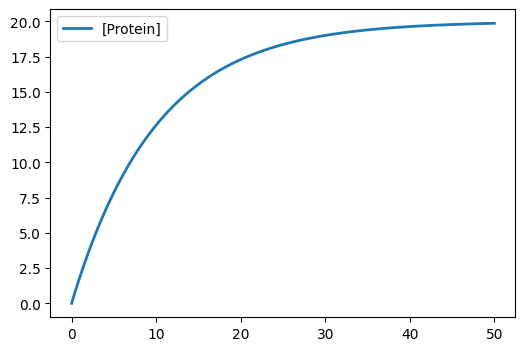

In [2]:


# A simple gene that produces protein and degrades it
model = te.loada('''
  production: -> Protein; k1
  degradation: Protein -> ; k2 * Protein

  k1 = 2.0    # production rate
  k2 = 0.1   # degradation rate
  Protein = 0 # starting amount
''')

result = model.simulate(0, 50, 500)
model.plot()

/tmp/ipykernel_4532/1679834414.py:30: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



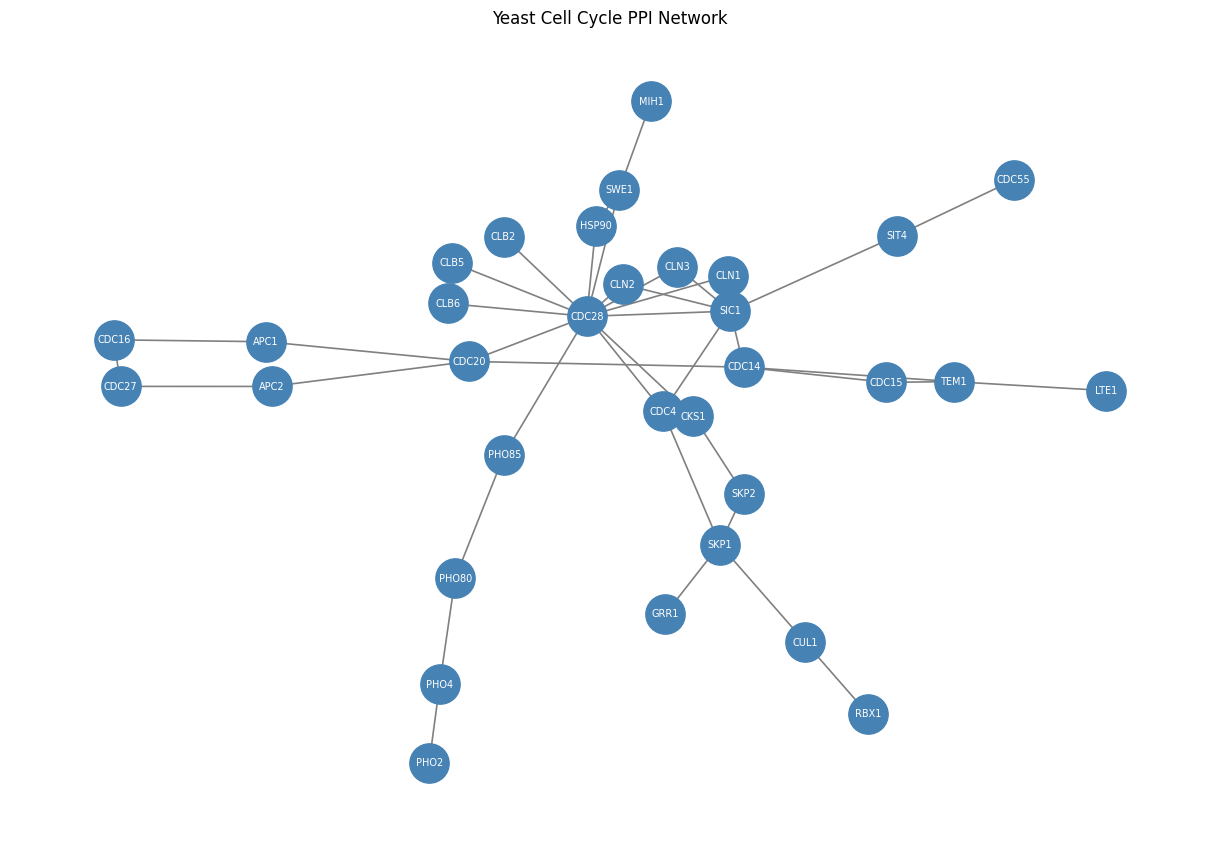

Nodes (proteins): 33
Edges (interactions): 41


In [3]:


# Real yeast PPI data — curated high-confidence interactions
# Source: BioGRID / Jeong et al. 2001 (Nature) core dataset
edges = [
    ("CDC28","CLN1"),("CDC28","CLN2"),("CDC28","CLN3"),
    ("CDC28","SIC1"),("CDC28","CDC20"),("CDC28","CKS1"),
    ("CLN1","SIC1"),("CLN2","SIC1"),("CLN3","SIC1"),
    ("SIC1","CDC4"),("CDC4","SKP1"),("SKP1","CUL1"),
    ("CUL1","RBX1"),("CDC20","APC1"),("APC1","CDC16"),
    ("CDC16","CDC27"),("CDC27","APC2"),("APC2","CDC20"),
    ("CKS1","SKP2"),("SKP2","SKP1"),("CLN1","CDC28"),
    ("SWE1","CDC28"),("MIH1","SWE1"),("HSP90","CDC28"),
    ("HSP90","SWE1"),("CDC55","SIT4"),("SIT4","SIC1"),
    ("CDC14","SIC1"),("CDC14","CDC20"),("TEM1","CDC14"),
    ("LTE1","TEM1"),("CDC15","TEM1"),("CDC15","CDC14"),
    ("CLB2","CDC28"),("CLB5","CDC28"),("CLB6","CDC28"),
    ("CDC28","PHO85"),("PHO85","PHO80"),("PHO80","PHO4"),
    ("PHO4","PHO2"),("GRR1","SKP1"),("CDC4","CDC28")
]

G = nx.Graph()
G.add_edges_from(edges)

# Visualize it
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
plt.title("Yeast Cell Cycle PPI Network")
plt.tight_layout()
plt.show()

print(f"Nodes (proteins): {G.number_of_nodes()}")
print(f"Edges (interactions): {G.number_of_edges()}")

In [4]:
# Degree of every protein
degree_dict = dict(G.degree())

for protein, deg in sorted(degree_dict.items(), key=lambda x: -x[1]):
    print(f"{protein}: {deg}")

CDC28: 13
SIC1: 7
CDC20: 4
SKP1: 4
CDC14: 4
CDC4: 3
SWE1: 3
TEM1: 3
CLN1: 2
CLN2: 2
CLN3: 2
CKS1: 2
CUL1: 2
APC1: 2
CDC16: 2
CDC27: 2
APC2: 2
SKP2: 2
HSP90: 2
SIT4: 2
CDC15: 2
PHO85: 2
PHO80: 2
PHO4: 2
RBX1: 1
MIH1: 1
CDC55: 1
LTE1: 1
CLB2: 1
CLB5: 1
CLB6: 1
PHO2: 1
GRR1: 1


/tmp/ipykernel_4532/1606370019.py:9: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



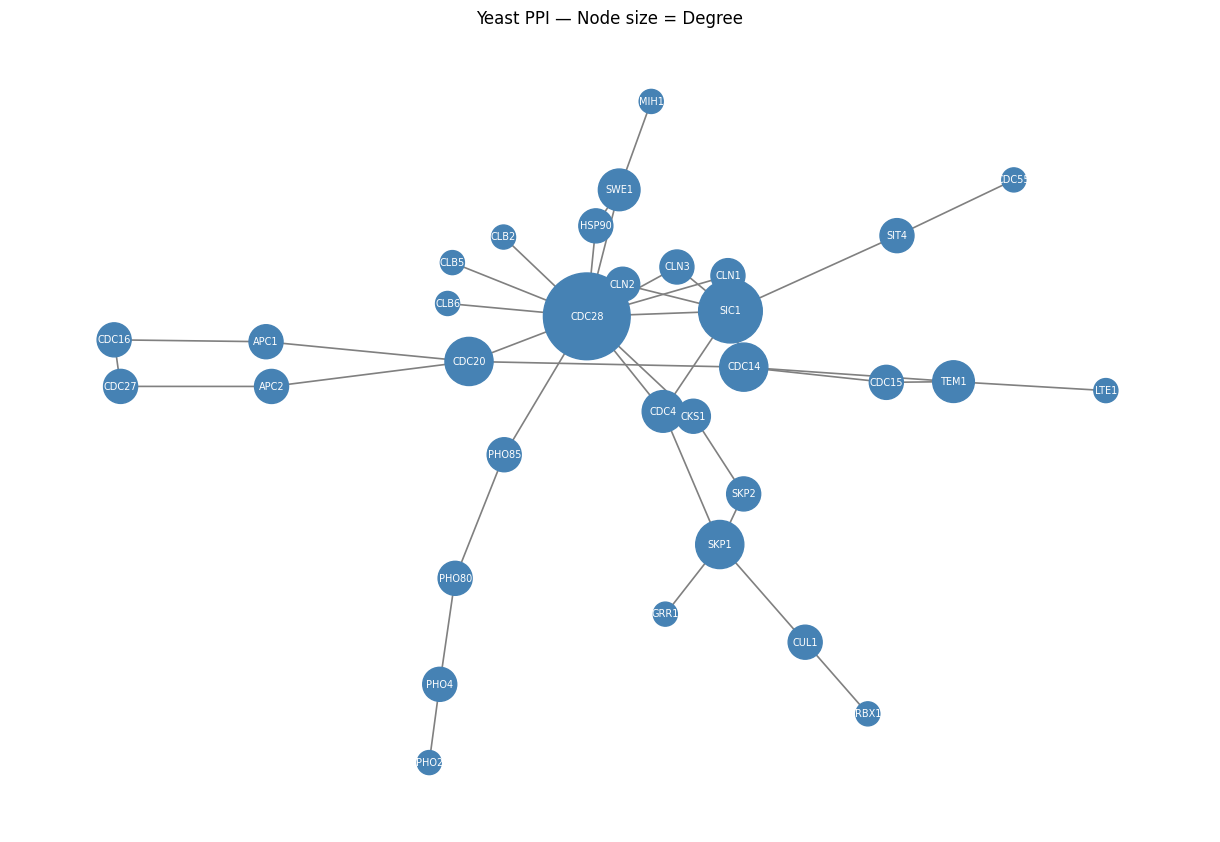

In [5]:
# Visualize with node size proportional to degree
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
node_sizes = [degree_dict[n] * 300 for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=node_sizes, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
plt.title("Yeast PPI — Node size = Degree")
plt.tight_layout()
plt.show()

In [6]:
# What happens to the network if we remove CDC28?
G_removed = G.copy()
G_removed.remove_node("CDC28")

# Count connected components
components = list(nx.connected_components(G_removed))
print(f"Components after removing CDC28: {len(components)}")
print()
for i, comp in enumerate(components):
    print(f"Component {i+1}: {comp}")

Components after removing CDC28: 6

Component 1: {'APC2', 'CLN1', 'CUL1', 'CDC14', 'CLN2', 'LTE1', 'APC1', 'SIC1', 'RBX1', 'SKP2', 'TEM1', 'CLN3', 'GRR1', 'CDC20', 'CKS1', 'SIT4', 'CDC4', 'SKP1', 'CDC15', 'CDC55', 'CDC16', 'CDC27'}
Component 2: {'MIH1', 'SWE1', 'HSP90'}
Component 3: {'CLB2'}
Component 4: {'CLB5'}
Component 5: {'CLB6'}
Component 6: {'PHO85', 'PHO4', 'PHO80', 'PHO2'}


In [7]:
#density

density = nx.density(G)
print(f"Network density: {density:.4f}")

# For context, let's see what density 1.0 would look like
n = G.number_of_nodes()
max_possible_edges = n * (n-1) / 2
actual_edges = G.number_of_edges()

print(f"Proteins in network: {n}")
print(f"Actual interactions: {actual_edges}")
print(f"Maximum possible interactions: {int(max_possible_edges)}")
print(f"Percentage of possible interactions that exist: {density*100:.2f}%")

Network density: 0.0777
Proteins in network: 33
Actual interactions: 41
Maximum possible interactions: 528
Percentage of possible interactions that exist: 7.77%


Shortest path from SIC1 to PHO4: ['SIC1', 'CDC28', 'PHO85', 'PHO80', 'PHO4']
Path length: 4 steps

Characteristic path length: 3.4432


/tmp/ipykernel_4532/3334594351.py:22: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



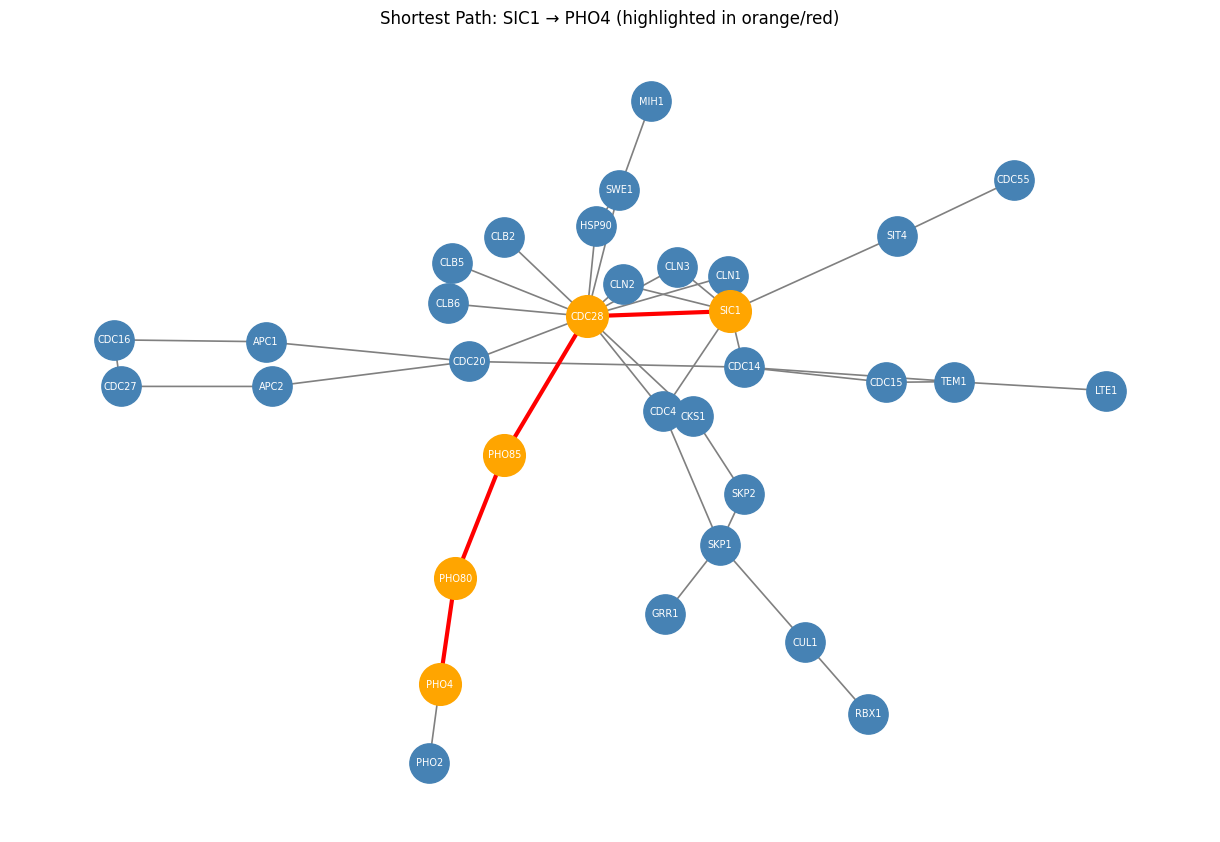

In [8]:
# Shortest path between two specific proteins
path = nx.shortest_path(G, "SIC1", "PHO4")
print(f"Shortest path from SIC1 to PHO4: {path}")
print(f"Path length: {len(path)-1} steps")

# Characteristic path length (average shortest path)
avg_path = nx.average_shortest_path_length(G)
print(f"\nCharacteristic path length: {avg_path:.4f}")

# Visualize the path
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path, path[1:]))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='red', width=3)
nx.draw_networkx_nodes(G, pos, nodelist=path,
                       node_color='orange', node_size=900)
plt.title("Shortest Path: SIC1 → PHO4 (highlighted in orange/red)")
plt.tight_layout()
plt.show()

Shortest path from SIC1 to SKP1: ['SIC1', 'CDC4', 'SKP1']
Path length: 4 steps


/tmp/ipykernel_4532/4130741712.py:19: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



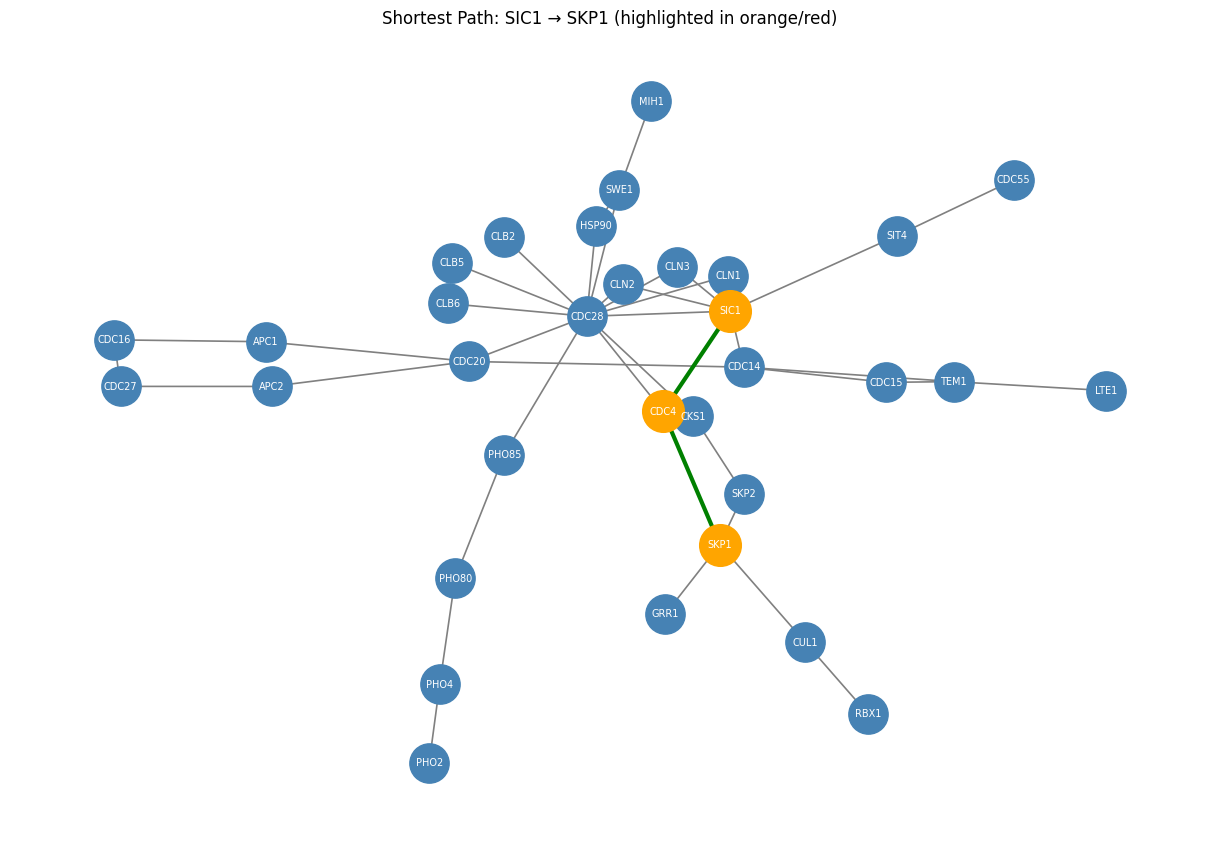

In [9]:
# Shortest path between two specific proteins
path_2 = nx.shortest_path(G, "SIC1", "SKP1")
print(f"Shortest path from SIC1 to SKP1: {path_2}")
print(f"Path length: {len(path)-1} steps")


# Visualize the path
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path_2, path_2[1:]))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='green', width=3)
nx.draw_networkx_nodes(G, pos, nodelist=path_2,
                       node_color='orange', node_size=900)
plt.title("Shortest Path: SIC1 → SKP1 (highlighted in orange/red)")
plt.tight_layout()
plt.show()


In [11]:
# Diameter of the network
diameter = nx.diameter(G)
print(f"Network diameter: {diameter}")

# Find which two proteins are furthest apart
periphery = nx.periphery(G)
center = nx.center(G)

print(f"\nPeriphery proteins (furthest from everything): {periphery}")
print(f"Center proteins (closest to everything): {center}")

# Find the actual longest shortest path
eccentricities = nx.eccentricity(G)
for protein, ecc in sorted(eccentricities.items(), key=lambda x: -x[1]):
    print(f"{protein}: eccentricity {ecc}")





Network diameter: 8

Periphery proteins (furthest from everything): ['RBX1', 'LTE1', 'PHO2']
Center proteins (closest to everything): ['CDC28']
RBX1: eccentricity 8
LTE1: eccentricity 8
PHO2: eccentricity 8
CUL1: eccentricity 7
CDC16: eccentricity 7
CDC27: eccentricity 7
CDC55: eccentricity 7
TEM1: eccentricity 7
CDC15: eccentricity 7
PHO4: eccentricity 7
GRR1: eccentricity 7
SKP1: eccentricity 6
APC1: eccentricity 6
APC2: eccentricity 6
SKP2: eccentricity 6
MIH1: eccentricity 6
SIT4: eccentricity 6
CDC14: eccentricity 6
PHO80: eccentricity 6
CLN1: eccentricity 5
CLN2: eccentricity 5
CLN3: eccentricity 5
SIC1: eccentricity 5
CDC20: eccentricity 5
CKS1: eccentricity 5
CDC4: eccentricity 5
SWE1: eccentricity 5
HSP90: eccentricity 5
CLB2: eccentricity 5
CLB5: eccentricity 5
CLB6: eccentricity 5
PHO85: eccentricity 5
CDC28: eccentricity 4


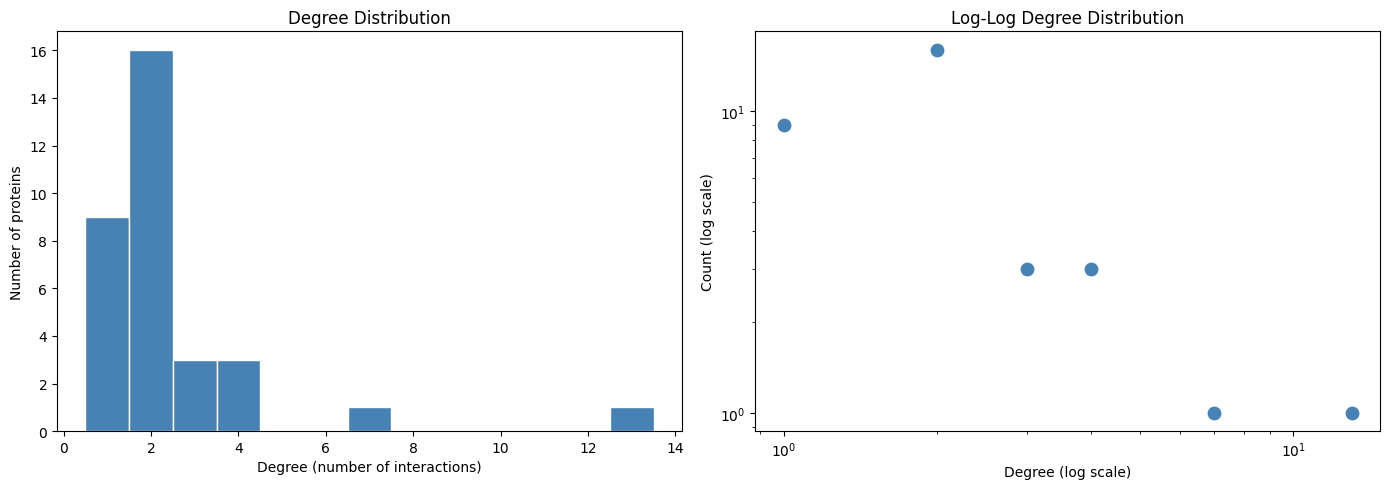

Degree : Number of proteins
  Degree  1 : 9 proteins  █████████
  Degree  2 : 16 proteins  ████████████████
  Degree  3 : 3 proteins  ███
  Degree  4 : 3 proteins  ███
  Degree  7 : 1 proteins  █
  Degree 13 : 1 proteins  █


In [12]:


# Get degree of all proteins
degrees = [d for n, d in G.degree()]

# Plot degree distribution
plt.figure(figsize=(14,5))

# Plot 1 — Raw distribution
plt.subplot(1,2,1)
plt.hist(degrees, bins=range(1, max(degrees)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel("Degree (number of interactions)")
plt.ylabel("Number of proteins")
plt.title("Degree Distribution")

# Plot 2 — Log-log plot
plt.subplot(1,2,2)
degree_counts = {}
for d in degrees:
    degree_counts[d] = degree_counts.get(d, 0) + 1

x = list(degree_counts.keys())
y = list(degree_counts.values())

plt.scatter(x, y, color='steelblue', s=80)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree (log scale)")
plt.ylabel("Count (log scale)")
plt.title("Log-Log Degree Distribution")

plt.tight_layout()
plt.show()

# Print the distribution
print("Degree : Number of proteins")
for deg, count in sorted(degree_counts.items()):
    print(f"  Degree {deg:2d} : {count} proteins  {'█' * count}")


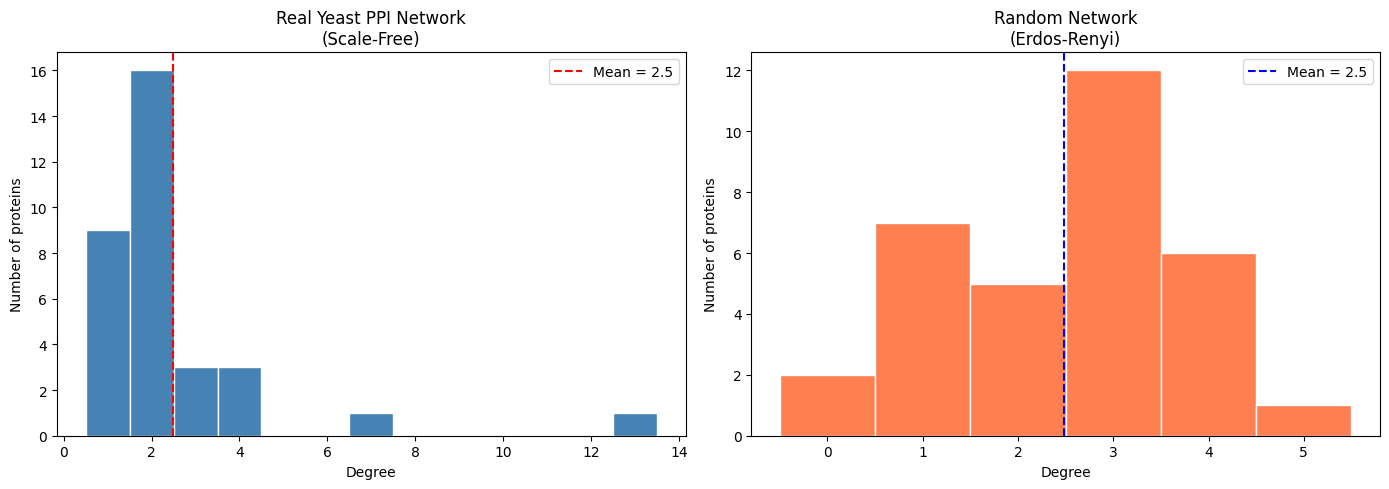

In [13]:
# Compare real network vs random network degree distribution
plt.figure(figsize=(14,5))

# Real network
plt.subplot(1,2,1)
real_degrees = [d for n, d in G.degree()]
plt.hist(real_degrees, bins=range(1, max(real_degrees)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel("Degree")
plt.ylabel("Number of proteins")
plt.title("Real Yeast PPI Network\n(Scale-Free)")
plt.axvline(np.mean(real_degrees), color='red',
            linestyle='--', label=f'Mean = {np.mean(real_degrees):.1f}')
plt.legend()

# Random network with same number of nodes and edges
random_G = nx.erdos_renyi_graph(G.number_of_nodes(),
                                 nx.density(G), seed=42)
random_degrees = [d for n, d in random_G.degree()]

plt.subplot(1,2,2)
plt.hist(random_degrees, bins=range(0, max(random_degrees)+2),
         color='coral', edgecolor='white', align='left')
plt.xlabel("Degree")
plt.ylabel("Number of proteins")
plt.title("Random Network\n(Erdos-Renyi)")
plt.axvline(np.mean(random_degrees), color='blue',
            linestyle='--', label=f'Mean = {np.mean(random_degrees):.1f}')
plt.legend()

plt.tight_layout()
plt.show()

Protein : Clustering Coefficient
----------------------------------------
CLN1       : 1.000  ████████████████████
CLN2       : 1.000  ████████████████████
CLN3       : 1.000  ████████████████████
HSP90      : 1.000  ████████████████████
CDC15      : 1.000  ████████████████████
CDC4       : 0.333  ██████
SWE1       : 0.333  ██████
TEM1       : 0.333  ██████
SIC1       : 0.190  ███
CDC14      : 0.167  ███
CDC28      : 0.064  █
CDC20      : 0.000  
CKS1       : 0.000  
SKP1       : 0.000  
CUL1       : 0.000  
RBX1       : 0.000  
APC1       : 0.000  
CDC16      : 0.000  
CDC27      : 0.000  
APC2       : 0.000  
SKP2       : 0.000  
MIH1       : 0.000  
CDC55      : 0.000  
SIT4       : 0.000  
LTE1       : 0.000  
CLB2       : 0.000  
CLB5       : 0.000  
CLB6       : 0.000  
PHO85      : 0.000  
PHO80      : 0.000  
PHO4       : 0.000  
PHO2       : 0.000  
GRR1       : 0.000  

Average clustering coefficient: 0.1946


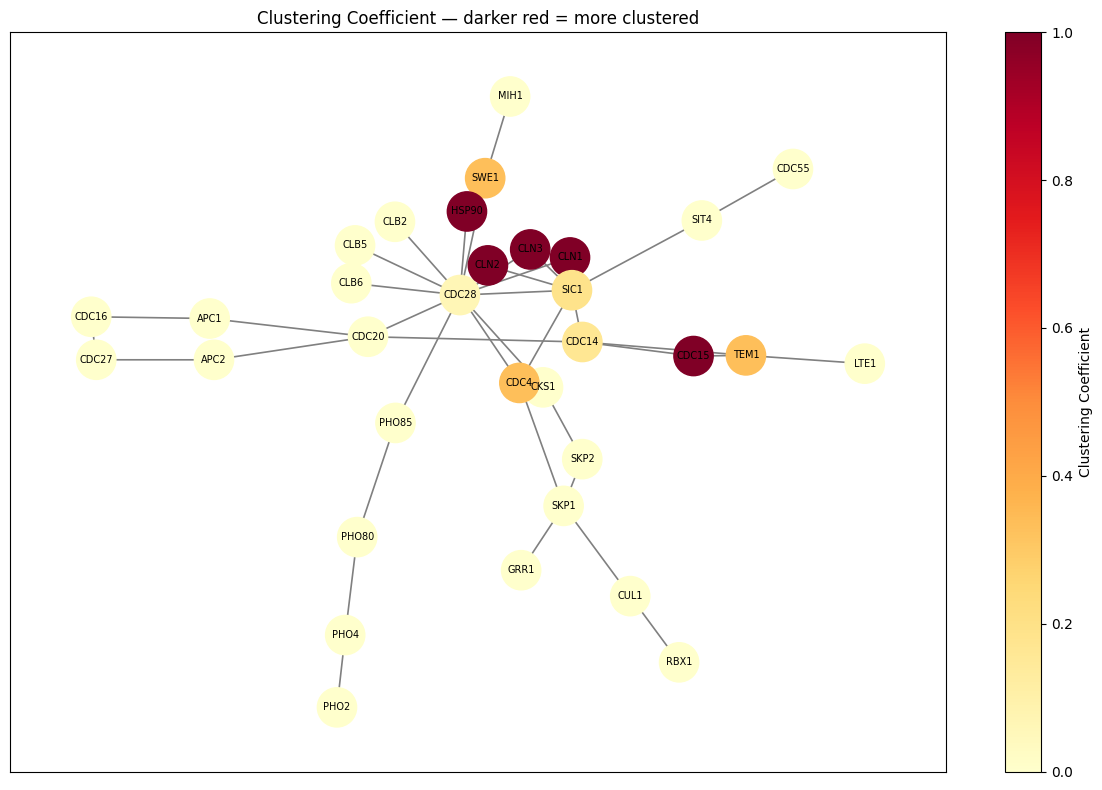

In [14]:
# Local clustering coefficient for each protein
clustering = nx.clustering(G)

print("Protein : Clustering Coefficient")
print("-" * 40)
for protein, cc in sorted(clustering.items(), key=lambda x: -x[1]):
    bar = '█' * int(cc * 20)
    print(f"{protein:10s} : {cc:.3f}  {bar}")

# Global clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f"\nAverage clustering coefficient: {avg_clustering:.4f}")

# Visualize — node color = clustering coefficient
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
cc_values = [clustering[n] for n in G.nodes()]
nodes = nx.draw_networkx_nodes(G, pos, node_color=cc_values,
                                cmap=plt.cm.YlOrRd,
                                node_size=800)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='black')
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.2)
plt.colorbar(nodes, label='Clustering Coefficient')
plt.title("Clustering Coefficient — darker red = more clustered")
plt.tight_layout()
plt.show()

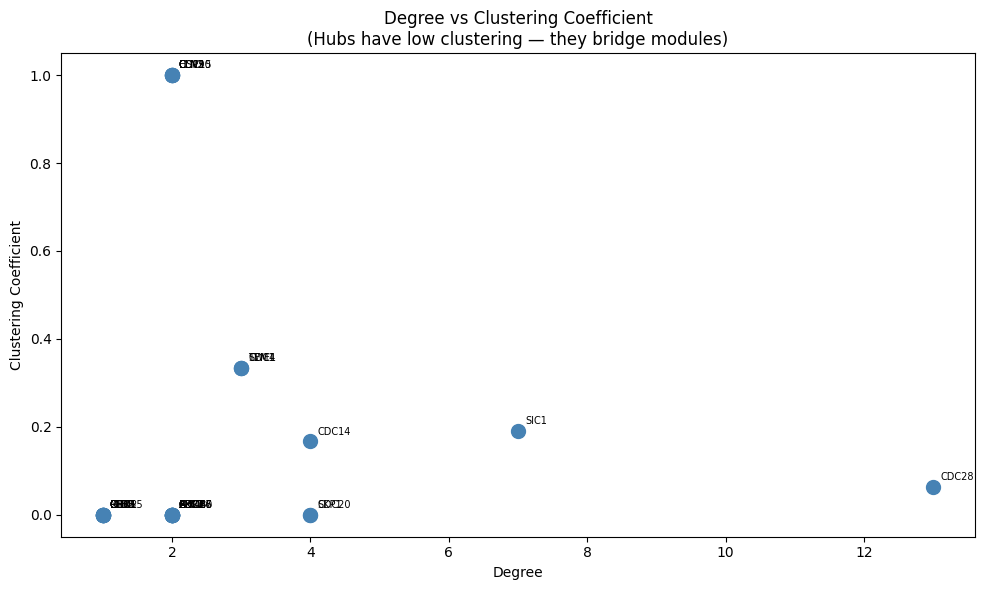

In [15]:
# Plot degree vs clustering coefficient
plt.figure(figsize=(10,6))
degrees_list = [G.degree(n) for n in G.nodes()]
clustering_list = [clustering[n] for n in G.nodes()]
labels = list(G.nodes())

plt.scatter(degrees_list, clustering_list,
            color='steelblue', s=100, zorder=5)

# Label each point
for i, label in enumerate(labels):
    plt.annotate(label,
                (degrees_list[i], clustering_list[i]),
                textcoords="offset points",
                xytext=(5,5), fontsize=7)

plt.xlabel("Degree")
plt.ylabel("Clustering Coefficient")
plt.title("Degree vs Clustering Coefficient\n(Hubs have low clustering — they bridge modules)")
plt.tight_layout()
plt.show()

Protein : Closeness Centrality
---------------------------------------------
CDC28      : 0.4923  ██████████████
SIC1       : 0.4211  ████████████
CDC20      : 0.4000  ████████████
CDC4       : 0.4000  ████████████
CLN1       : 0.3596  ██████████
CLN2       : 0.3596  ██████████
CLN3       : 0.3596  ██████████
CKS1       : 0.3556  ██████████
PHO85      : 0.3556  ██████████
CDC14      : 0.3516  ██████████
SWE1       : 0.3441  ██████████
HSP90      : 0.3404  ██████████
CLB2       : 0.3333  ██████████
CLB5       : 0.3333  ██████████
CLB6       : 0.3333  ██████████
SKP1       : 0.3137  █████████
SIT4       : 0.3048  █████████
APC1       : 0.2963  ████████
APC2       : 0.2963  ████████
SKP2       : 0.2857  ████████
PHO80      : 0.2735  ████████
TEM1       : 0.2689  ████████
CDC15      : 0.2667  ████████
MIH1       : 0.2581  ███████
CUL1       : 0.2443  ███████
GRR1       : 0.2406  ███████
CDC16      : 0.2353  ███████
CDC27      : 0.2353  ███████
CDC55      : 0.2353  ███████
PHO4       : 0.21

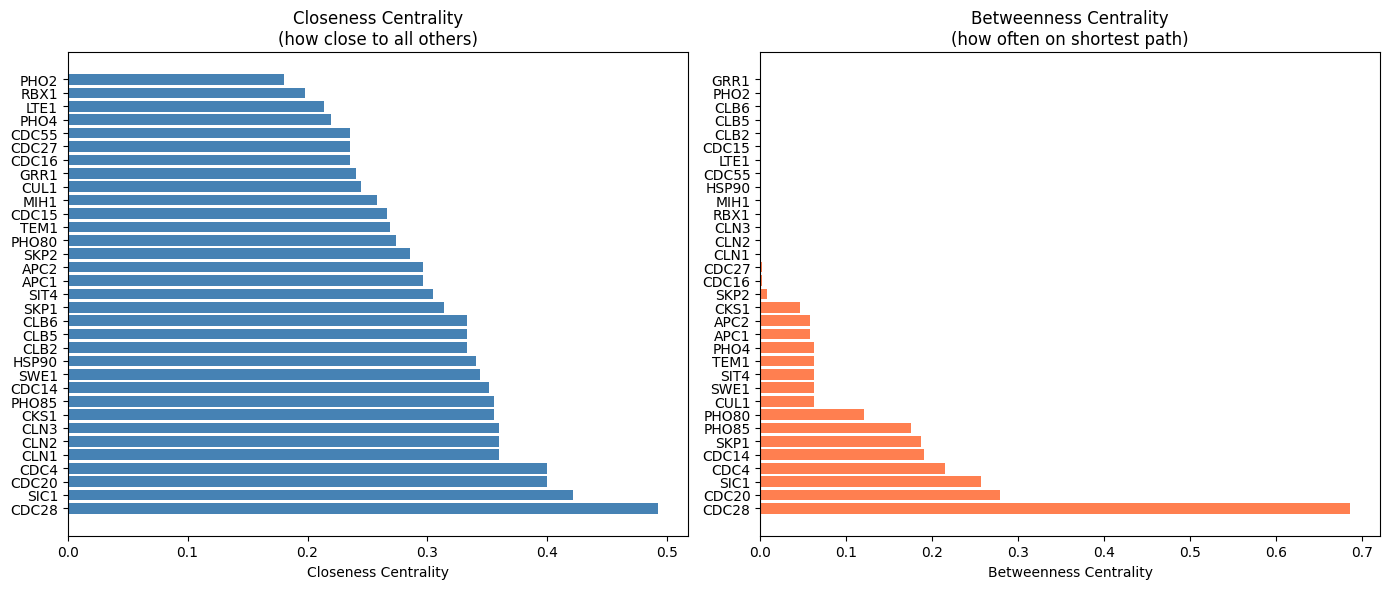

In [16]:
# Closeness centrality
closeness = nx.closeness_centrality(G)

print("Protein : Closeness Centrality")
print("-" * 45)
for protein, cc in sorted(closeness.items(), key=lambda x: -x[1]):
    bar = '█' * int(cc * 30)
    print(f"{protein:10s} : {cc:.4f}  {bar}")

# Betweenness centrality — how often does a protein
# sit on the shortest path between two other proteins
betweenness = nx.betweenness_centrality(G)

print("\nProtein : Betweenness Centrality")
print("-" * 45)
for protein, bc in sorted(betweenness.items(), key=lambda x: -x[1]):
    bar = '█' * int(bc * 40)
    print(f"{protein:10s} : {bc:.4f}  {bar}")

# Plot both together
plt.figure(figsize=(14,6))

proteins = list(G.nodes())
close_vals = [closeness[p] for p in proteins]
between_vals = [betweenness[p] for p in proteins]

plt.subplot(1,2,1)
sorted_close = sorted(closeness.items(), key=lambda x: -x[1])
plt.barh([x[0] for x in sorted_close],
         [x[1] for x in sorted_close],
         color='steelblue')
plt.xlabel("Closeness Centrality")
plt.title("Closeness Centrality\n(how close to all others)")
plt.tight_layout()

plt.subplot(1,2,2)
sorted_between = sorted(betweenness.items(), key=lambda x: -x[1])
plt.barh([x[0] for x in sorted_between],
         [x[1] for x in sorted_between],
         color='coral')
plt.xlabel("Betweenness Centrality")
plt.title("Betweenness Centrality\n(how often on shortest path)")
plt.tight_layout()

plt.tight_layout()
plt.show()

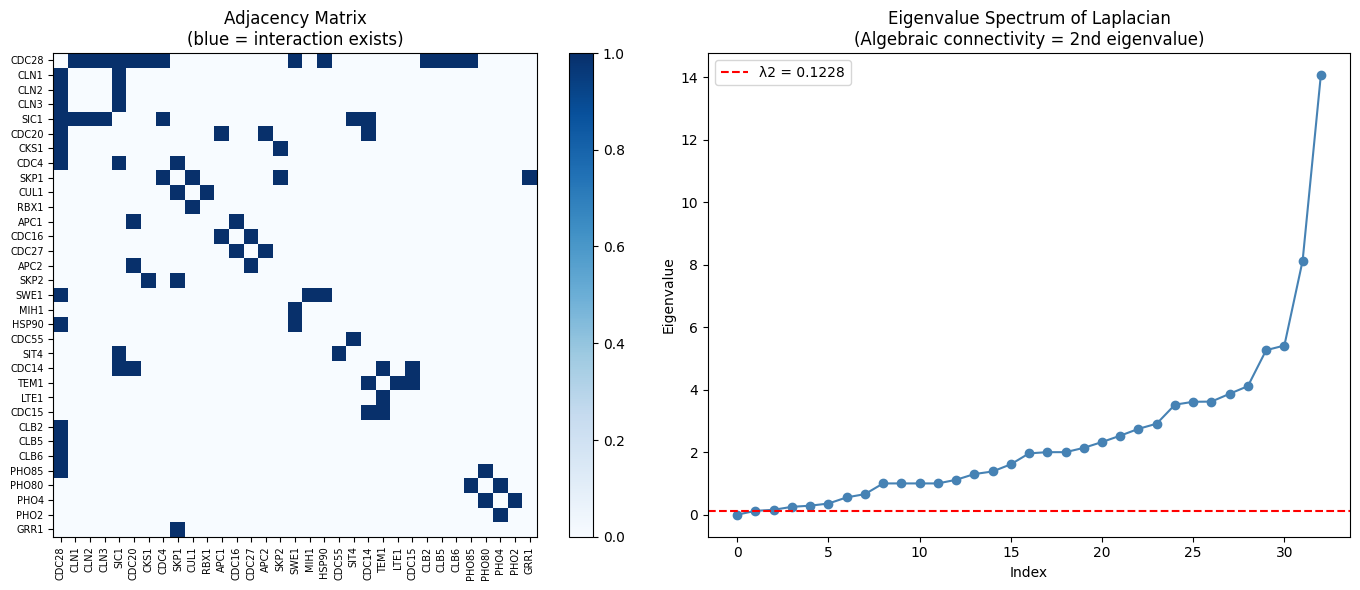

Number of zero eigenvalues: 1
Algebraic connectivity (λ2): 0.1228
Spectral gap (λ2 - λ1): 0.1228
Largest eigenvalue: 14.0669


In [17]:
#spectral graph theory

# Get the adjacency matrix
adj_matrix = nx.adjacency_matrix(G).toarray()
proteins = list(G.nodes())

# Plot adjacency matrix
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(adj_matrix, cmap='Blues', interpolation='none')
plt.xticks(range(len(proteins)), proteins, rotation=90, fontsize=7)
plt.yticks(range(len(proteins)), proteins, fontsize=7)
plt.title("Adjacency Matrix\n(blue = interaction exists)")
plt.colorbar()

# Compute Laplacian matrix
L = nx.laplacian_matrix(G).toarray()

# Compute eigenvalues
eigenvalues = np.linalg.eigvalsh(L)
eigenvalues_sorted = np.sort(eigenvalues)

plt.subplot(1,2,2)
plt.plot(eigenvalues_sorted, 'o-', color='steelblue', markersize=6)
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Laplacian\n(Algebraic connectivity = 2nd eigenvalue)")
plt.axhline(y=eigenvalues_sorted[1], color='red',
            linestyle='--',
            label=f'λ2 = {eigenvalues_sorted[1]:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Key spectral properties
print(f"Number of zero eigenvalues: {sum(1 for e in eigenvalues_sorted if e < 1e-10)}")
print(f"Algebraic connectivity (λ2): {eigenvalues_sorted[1]:.4f}")
print(f"Spectral gap (λ2 - λ1): {eigenvalues_sorted[1] - eigenvalues_sorted[0]:.4f}")
print(f"Largest eigenvalue: {eigenvalues_sorted[-1]:.4f}")

In [18]:
# Spectral confirmation of what happens when CDC28 is removed
G_removed = G.copy()
G_removed.remove_node("CDC28")
L_removed = nx.laplacian_matrix(G_removed).toarray()
eigenvalues_removed = np.sort(np.linalg.eigvalsh(L_removed))
zero_count = sum(1 for e in eigenvalues_removed if e < 1e-10)
print(f"Zero eigenvalues after removing CDC28: {zero_count}")

Zero eigenvalues after removing CDC28: 6


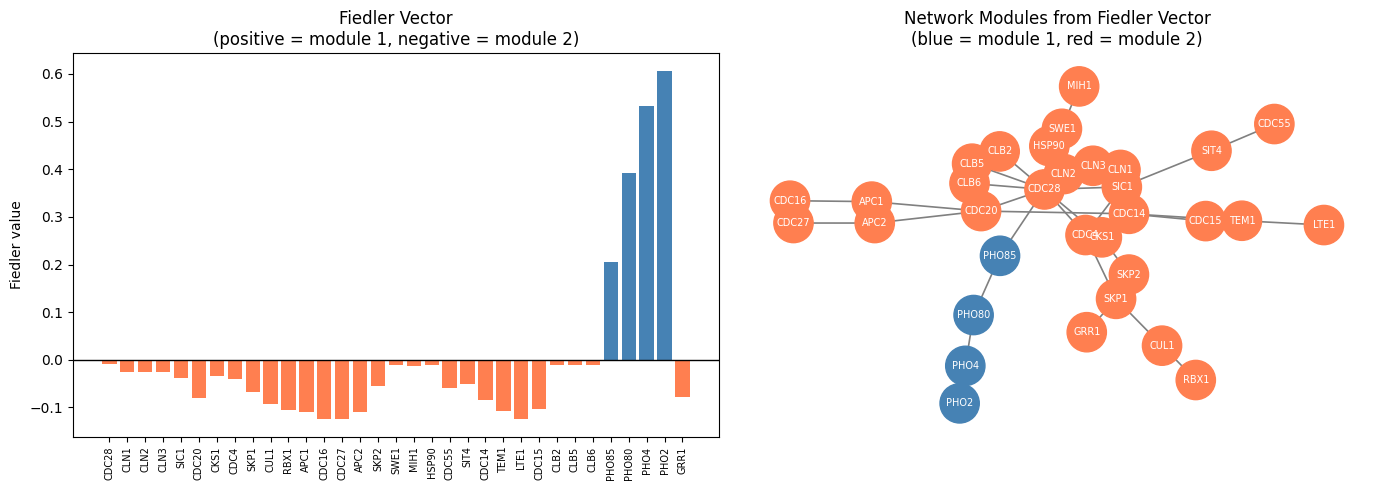

Module 1 (blue): ['PHO85', 'PHO80', 'PHO4', 'PHO2']
Module 2 (red): ['CDC28', 'CLN1', 'CLN2', 'CLN3', 'SIC1', 'CDC20', 'CKS1', 'CDC4', 'SKP1', 'CUL1', 'RBX1', 'APC1', 'CDC16', 'CDC27', 'APC2', 'SKP2', 'SWE1', 'MIH1', 'HSP90', 'CDC55', 'SIT4', 'CDC14', 'TEM1', 'LTE1', 'CDC15', 'CLB2', 'CLB5', 'CLB6', 'GRR1']


In [19]:
# Compute full eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Fiedler vector = eigenvector of second smallest eigenvalue
fiedler_vector = eigenvectors[:, 1]

# Plot Fiedler vector
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
colors = ['steelblue' if v > 0 else 'coral' for v in fiedler_vector]
plt.bar(range(len(proteins)), fiedler_vector, color=colors)
plt.xticks(range(len(proteins)), proteins, rotation=90, fontsize=7)
plt.axhline(y=0, color='black', linewidth=1)
plt.title("Fiedler Vector\n(positive = module 1, negative = module 2)")
plt.ylabel("Fiedler value")
plt.tight_layout()

# Visualize modules on network
plt.subplot(1,2,2)
pos = nx.spring_layout(G, seed=42)
node_colors = ['steelblue' if fiedler_vector[i] > 0
               else 'coral' for i in range(len(proteins))]
nx.draw(G, pos, with_labels=True,
        node_color=node_colors,
        node_size=800, font_size=7,
        font_color='white', edge_color='gray', width=1.2)
plt.title("Network Modules from Fiedler Vector\n(blue = module 1, red = module 2)")
plt.tight_layout()
plt.show()

# Print which proteins fall in which module
module1 = [proteins[i] for i in range(len(proteins)) if fiedler_vector[i] > 0]
module2 = [proteins[i] for i in range(len(proteins)) if fiedler_vector[i] < 0]
print(f"Module 1 (blue): {module1}")
print(f"Module 2 (red): {module2}")

In [20]:
# Where exactly is CDC28 in the Fiedler vector?
cdc28_idx = proteins.index("CDC28")
cdc28_fiedler = fiedler_vector[cdc28_idx]

print(f"CDC28 Fiedler value: {cdc28_fiedler:.4f}")
print()

# Show all proteins sorted by Fiedler value
print("Proteins sorted by Fiedler value:")
print("-" * 45)
sorted_fiedler = sorted(zip(proteins, fiedler_vector), key=lambda x: x[1])
for protein, val in sorted_fiedler:
    bar_pos = int(abs(val) * 30)
    if val < 0:
        print(f"{protein:10s} : {val:+.4f}  {'█' * bar_pos} (Module 2)")
    else:
        print(f"{protein:10s} : {val:+.4f}  {'█' * bar_pos} (Module 1)")

CDC28 Fiedler value: -0.0089

Proteins sorted by Fiedler value:
---------------------------------------------
CDC16      : -0.1246  ███ (Module 2)
CDC27      : -0.1246  ███ (Module 2)
LTE1       : -0.1231  ███ (Module 2)
APC2       : -0.1093  ███ (Module 2)
APC1       : -0.1093  ███ (Module 2)
TEM1       : -0.1080  ███ (Module 2)
RBX1       : -0.1056  ███ (Module 2)
CDC15      : -0.1028  ███ (Module 2)
CUL1       : -0.0927  ██ (Module 2)
CDC14      : -0.0849  ██ (Module 2)
CDC20      : -0.0806  ██ (Module 2)
GRR1       : -0.0779  ██ (Module 2)
SKP1       : -0.0683  ██ (Module 2)
CDC55      : -0.0584  █ (Module 2)
SKP2       : -0.0543  █ (Module 2)
SIT4       : -0.0512  █ (Module 2)
CDC4       : -0.0400  █ (Module 2)
SIC1       : -0.0377  █ (Module 2)
CKS1       : -0.0337  █ (Module 2)
CLN2       : -0.0249   (Module 2)
CLN3       : -0.0249   (Module 2)
CLN1       : -0.0249   (Module 2)
MIH1       : -0.0129   (Module 2)
SWE1       : -0.0114   (Module 2)
HSP90      : -0.0108   (Module 2)


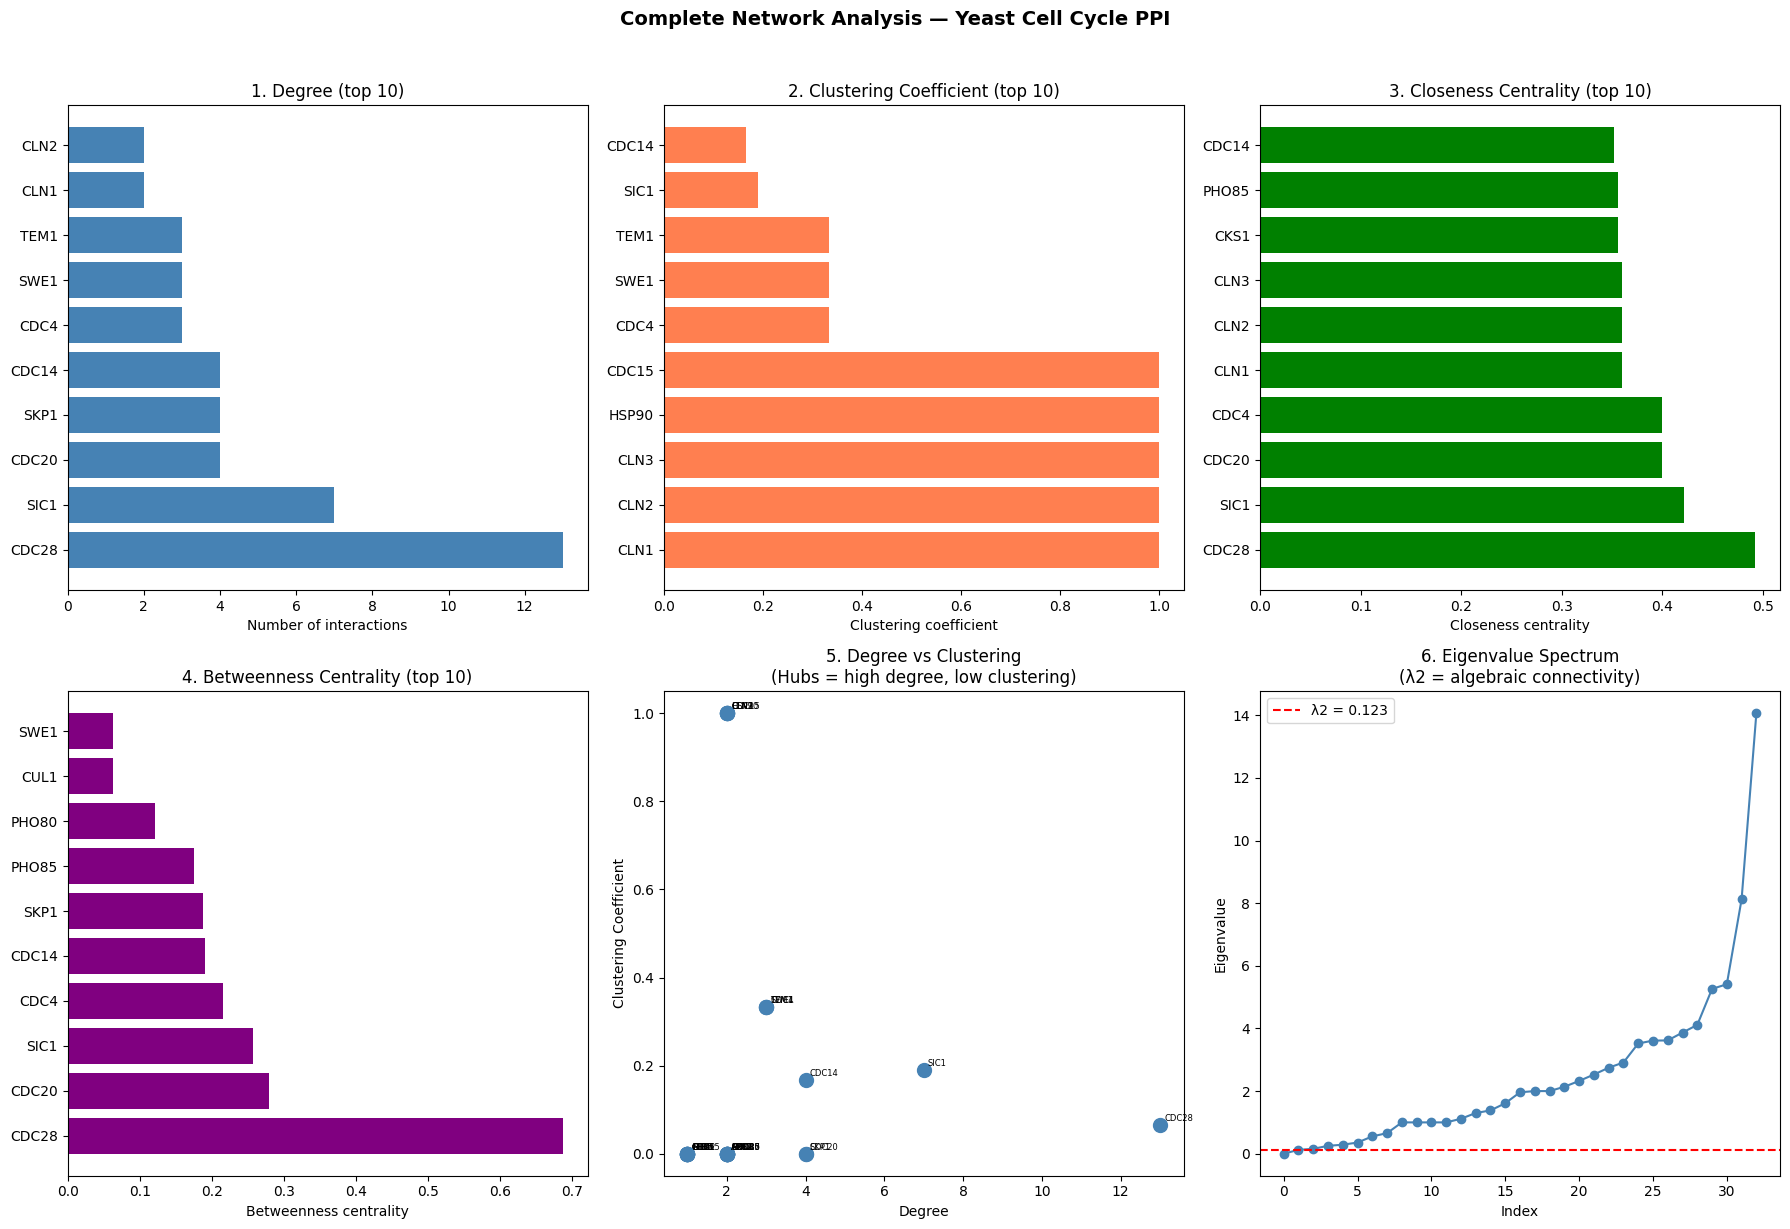

In [21]:
# Master summary visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Degree
ax1 = axes[0,0]
degree_dict = dict(G.degree())
sorted_deg = sorted(degree_dict.items(), key=lambda x: -x[1])
ax1.barh([x[0] for x in sorted_deg[:10]],
         [x[1] for x in sorted_deg[:10]], color='steelblue')
ax1.set_title("1. Degree (top 10)")
ax1.set_xlabel("Number of interactions")

# 2. Clustering coefficient
ax2 = axes[0,1]
sorted_cc = sorted(clustering.items(), key=lambda x: -x[1])[:10]
ax2.barh([x[0] for x in sorted_cc],
         [x[1] for x in sorted_cc], color='coral')
ax2.set_title("2. Clustering Coefficient (top 10)")
ax2.set_xlabel("Clustering coefficient")

# 3. Closeness centrality
ax3 = axes[0,2]
sorted_close = sorted(closeness.items(), key=lambda x: -x[1])[:10]
ax3.barh([x[0] for x in sorted_close],
         [x[1] for x in sorted_close], color='green')
ax3.set_title("3. Closeness Centrality (top 10)")
ax3.set_xlabel("Closeness centrality")

# 4. Betweenness centrality
ax4 = axes[1,0]
sorted_between = sorted(betweenness.items(), key=lambda x: -x[1])[:10]
ax4.barh([x[0] for x in sorted_between],
         [x[1] for x in sorted_between], color='purple')
ax4.set_title("4. Betweenness Centrality (top 10)")
ax4.set_xlabel("Betweenness centrality")

# 5. Degree vs clustering
ax5 = axes[1,1]
deg_vals = [G.degree(n) for n in G.nodes()]
cc_vals = [clustering[n] for n in G.nodes()]
ax5.scatter(deg_vals, cc_vals, color='steelblue', s=100)
for i, p in enumerate(G.nodes()):
    ax5.annotate(p, (deg_vals[i], cc_vals[i]), fontsize=6,
                xytext=(3,3), textcoords='offset points')
ax5.set_xlabel("Degree")
ax5.set_ylabel("Clustering Coefficient")
ax5.set_title("5. Degree vs Clustering\n(Hubs = high degree, low clustering)")

# 6. Eigenvalue spectrum
ax6 = axes[1,2]
ax6.plot(eigenvalues_sorted, 'o-', color='steelblue', markersize=6)
ax6.axhline(y=eigenvalues_sorted[1], color='red', linestyle='--',
            label=f'λ2 = {eigenvalues_sorted[1]:.3f}')
ax6.set_xlabel("Index")
ax6.set_ylabel("Eigenvalue")
ax6.set_title("6. Eigenvalue Spectrum\n(λ2 = algebraic connectivity)")
ax6.legend()

plt.suptitle("Complete Network Analysis — Yeast Cell Cycle PPI",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Let's understand diameter step by step
print("=== DIAMETER EXPLAINED STEP BY STEP ===\n")

# Step 1 — shortest path between every pair
print("Shortest path lengths between ALL protein pairs:")
print("-" * 50)

all_paths = {}
for source in G.nodes():
    for target in G.nodes():
        if source != target:
            path_length = nx.shortest_path_length(G, source, target)
            all_paths[(source, target)] = path_length

# Show a sample
sample_pairs = list(all_paths.items())[:10]
for (src, tgt), length in sample_pairs:
    path = nx.shortest_path(G, src, tgt)
    print(f"{src:8s} → {tgt:8s} : {length} steps  {' → '.join(path)}")

# Step 2 — find the maximum
print(f"\n=== NOW FIND THE MAXIMUM OF ALL THESE ===")
max_length = max(all_paths.values())
max_pairs = [(pair, length) for pair, length
             in all_paths.items() if length == max_length]

print(f"\nDiameter = {max_length}")
print(f"\nProtein pairs that are furthest apart:")
for (src, tgt), length in max_pairs[:5]:
    path = nx.shortest_path(G, src, tgt)
    print(f"{src} → {tgt} : {' → '.join(path)}")

=== DIAMETER EXPLAINED STEP BY STEP ===

Shortest path lengths between ALL protein pairs:
--------------------------------------------------
CDC28    → CLN1     : 1 steps  CDC28 → CLN1
CDC28    → CLN2     : 1 steps  CDC28 → CLN2
CDC28    → CLN3     : 1 steps  CDC28 → CLN3
CDC28    → SIC1     : 1 steps  CDC28 → SIC1
CDC28    → CDC20    : 1 steps  CDC28 → CDC20
CDC28    → CKS1     : 1 steps  CDC28 → CKS1
CDC28    → CDC4     : 1 steps  CDC28 → CDC4
CDC28    → SKP1     : 2 steps  CDC28 → CDC4 → SKP1
CDC28    → CUL1     : 3 steps  CDC28 → CDC4 → SKP1 → CUL1
CDC28    → RBX1     : 4 steps  CDC28 → CDC4 → SKP1 → CUL1 → RBX1

=== NOW FIND THE MAXIMUM OF ALL THESE ===

Diameter = 8

Protein pairs that are furthest apart:
RBX1 → PHO2 : RBX1 → CUL1 → SKP1 → CDC4 → CDC28 → PHO85 → PHO80 → PHO4 → PHO2
LTE1 → PHO2 : LTE1 → TEM1 → CDC14 → SIC1 → CDC28 → PHO85 → PHO80 → PHO4 → PHO2
PHO2 → RBX1 : PHO2 → PHO4 → PHO80 → PHO85 → CDC28 → CDC4 → SKP1 → CUL1 → RBX1
PHO2 → LTE1 : PHO2 → PHO4 → PHO80 → PHO85 → 

/tmp/ipykernel_4532/2174223910.py:41: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



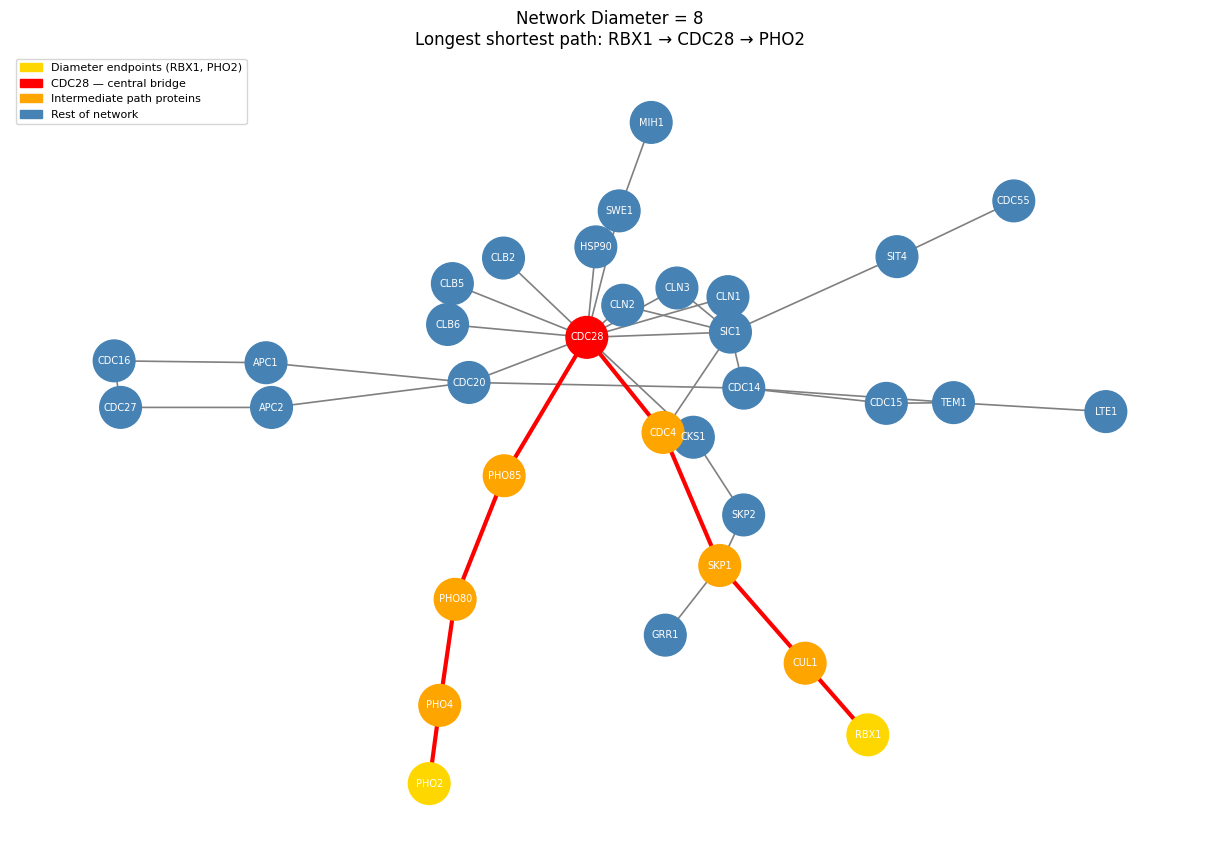

=== DIAMETER IN CONTEXT ===
Network size: 33 proteins
Diameter: 8 steps
Characteristic path length: 3.443 steps
Ratio diameter/size: 0.242

Interpretation: worst case signal travel is only
24.2% of network size
This confirms small-world architecture


In [23]:
# Visualize the diameter path on the network
diameter_path = ['RBX1','CUL1','SKP1','CDC4',
                 'CDC28','PHO85','PHO80','PHO4','PHO2']

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)

# Color nodes by their role in the path
node_colors = []
for node in G.nodes():
    if node == 'CDC28':
        node_colors.append('red')        # hub — the bridge
    elif node in ['RBX1','PHO2']:
        node_colors.append('gold')       # endpoints — periphery
    elif node in diameter_path:
        node_colors.append('orange')     # intermediate path nodes
    else:
        node_colors.append('steelblue')  # rest of network

# Draw full network
nx.draw(G, pos, with_labels=True,
        node_color=node_colors,
        node_size=900, font_size=7,
        font_color='white', edge_color='gray', width=1.2)

# Highlight diameter path edges
path_edges = list(zip(diameter_path, diameter_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='red', width=3)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='gold', label='Diameter endpoints (RBX1, PHO2)'),
    Patch(color='red', label='CDC28 — central bridge'),
    Patch(color='orange', label='Intermediate path proteins'),
    Patch(color='steelblue', label='Rest of network')
]
plt.legend(handles=legend, loc='upper left', fontsize=8)
plt.title("Network Diameter = 8\nLongest shortest path: RBX1 → CDC28 → PHO2")
plt.tight_layout()
plt.show()

# Summary statistics
print("=== DIAMETER IN CONTEXT ===")
print(f"Network size: {G.number_of_nodes()} proteins")
print(f"Diameter: {nx.diameter(G)} steps")
print(f"Characteristic path length: {nx.average_shortest_path_length(G):.3f} steps")
print(f"Ratio diameter/size: {nx.diameter(G)/G.number_of_nodes():.3f}")
print(f"\nInterpretation: worst case signal travel is only")
print(f"{nx.diameter(G)/G.number_of_nodes()*100:.1f}% of network size")
print(f"This confirms small-world architecture")